In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
training_data = datasets.MNIST(root="data", train=True, transform=ToTensor(), download=True)
test_data = datasets.MNIST(root="data", train=False, transform=ToTensor(), download=True)

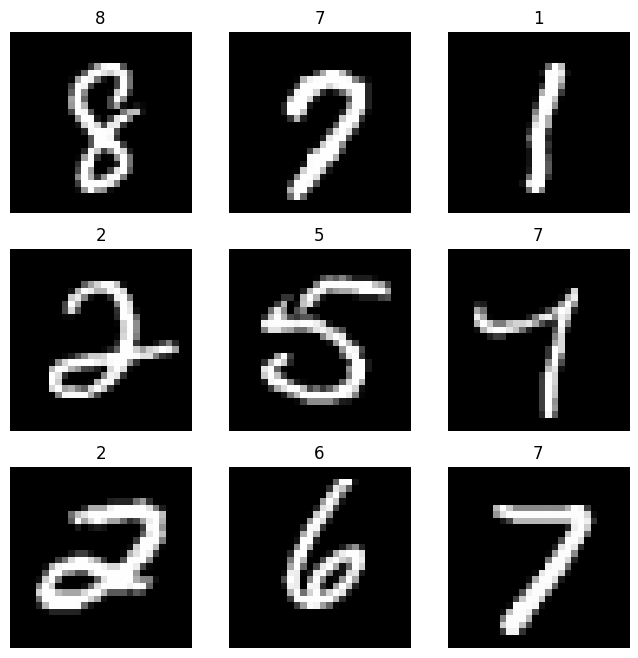

In [3]:
label_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1, )).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [4]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [5]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"using {device} device")

using mps device


In [6]:
class NerualNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [7]:
model = NerualNetwork().to(device)

In [ ]:
learning_rate = 1e-3
batch_size = 64
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss {loss:>7f}\t[{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"test error: \n accuracy: {(100*correct):>0.1f}%, average loss: {test_loss:8>f} \n")

In [10]:
epochs = 10
for t in range(epochs):
    print(f"epoch {t + 1}\n-------------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

epoch 1
-------------------------------------
loss 2.304692	[   64/60000]
loss 0.353511	[ 6464/60000]
loss 0.373275	[12864/60000]
loss 0.172311	[19264/60000]
loss 0.068757	[25664/60000]
loss 0.175953	[32064/60000]
loss 0.113211	[38464/60000]
loss 0.076843	[44864/60000]
loss 0.101017	[51264/60000]
loss 0.113479	[57664/60000]
test error: 
 accuracy: 96.0%, average loss: 0.132901 

epoch 2
-------------------------------------
loss 0.214438	[   64/60000]
loss 0.059679	[ 6464/60000]
loss 0.053158	[12864/60000]
loss 0.274909	[19264/60000]
loss 0.326326	[25664/60000]
loss 0.038259	[32064/60000]
loss 0.037351	[38464/60000]
loss 0.122406	[44864/60000]
loss 0.090664	[51264/60000]
loss 0.139252	[57664/60000]
test error: 
 accuracy: 96.5%, average loss: 0.103082 

epoch 3
-------------------------------------
loss 0.039317	[   64/60000]
loss 0.035971	[ 6464/60000]
loss 0.057606	[12864/60000]
loss 0.314278	[19264/60000]
loss 0.024919	[25664/60000]
loss 0.163986	[32064/60000]
loss 0.073305	[38464/6

In [24]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(
                1, 32, kernel_size=3, stride=1, padding=1
            ),  # (28 - 3 - 2(1) / 1) + 1 = 28
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 x 28 x 28 -> 32 x 14 x 14
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32 x 14 x 14 -> 32 x 7 x 7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        logits = self.sequential(x)
        return logits

In [26]:
model = ConvolutionalNetwork().to(device)

learning_rate = 1e-3
batch_size = 64
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [27]:
epochs = 10
for t in range(epochs):
    print(f"epoch {t + 1}\n-------------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

epoch 1
-------------------------------------
loss 2.309586	[   64/60000]
loss 0.372486	[ 6464/60000]
loss 0.211296	[12864/60000]
loss 0.068801	[19264/60000]
loss 0.168655	[25664/60000]
loss 0.030347	[32064/60000]
loss 0.026696	[38464/60000]
loss 0.023240	[44864/60000]
loss 0.065942	[51264/60000]
loss 0.050309	[57664/60000]
test error: 
 accuracy: 98.2%, average loss: 0.053920 

epoch 2
-------------------------------------
loss 0.036977	[   64/60000]
loss 0.007673	[ 6464/60000]
loss 0.071842	[12864/60000]
loss 0.066187	[19264/60000]
loss 0.022789	[25664/60000]
loss 0.054518	[32064/60000]
loss 0.030161	[38464/60000]
loss 0.002815	[44864/60000]
loss 0.113243	[51264/60000]
loss 0.052688	[57664/60000]
test error: 
 accuracy: 98.6%, average loss: 0.037298 

epoch 3
-------------------------------------
loss 0.021835	[   64/60000]
loss 0.182524	[ 6464/60000]
loss 0.014835	[12864/60000]
loss 0.014578	[19264/60000]
loss 0.047987	[25664/60000]
loss 0.104927	[32064/60000]
loss 0.012740	[38464/6